<a href="https://colab.research.google.com/github/Ishitha1/Flood-Detection-Watershed-Segmentation/blob/main/Flood_Detection_Watershed_Using_Otsu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flood Area Segmentation - Watershed-based approach

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
from skimage import io

Mounted at /content/drive


## Paths

In [ ]:
BASE_DIR = Path("/content/drive/MyDrive/flood-yolo-training/flood-dataset")
IMG_DIR  = BASE_DIR / "Image"
MASK_DIR = BASE_DIR / "Mask"
META_FILE = BASE_DIR / "metadata.csv"

print("Number of images:", len(list(IMG_DIR.glob("*.jpg"))))
print("Number of masks  :", len(list(MASK_DIR.glob("*.png"))))

Number of images: 290
Number of masks  : 290


# 2. Choose & Load one example

In [ ]:
filename = "11.jpg"

img_path = IMG_DIR / filename
mask_path = MASK_DIR / (filename.replace(".jpg", ".png"))

print("Processing:", filename)

orig = cv2.imread(str(img_path))
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

ground_truth = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

if orig is None or ground_truth is None:
    raise FileNotFoundError(f"Cannot read {filename}")

print("Image shape:", orig.shape)
print("Mask  shape:", ground_truth.shape)

Processing: 11.jpg
Image shape: (1800, 2400, 3)
Mask  shape: (1800, 2400)


# 3. Preprocessing

In [ ]:
gray = cv2.cvtColor(orig, cv2.COLOR_RGB2GRAY)

# Gaussian blur - remove noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# CLAHE contrast enhancement (very helpful for flood images)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(blurred)

# 4. Thresholding (Otsu)

In [ ]:
_, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5. Noise removal

In [ ]:
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

# 6. Sure background & foreground

In [ ]:
# Sure background = big dilation
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Distance transform → sure foreground
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Unknown region = bg - fg
unknown = cv2.subtract(sure_bg, sure_fg)

# 7. Marker labelling

In [ ]:
# Connected components on sure foreground
_, markers = cv2.connectedComponents(sure_fg)

# Add 1 → background becomes 1, objects 2,3,4,...
markers = markers + 1

# Unknown regions get 0 (watershed will label them)
markers[unknown == 255] = 0

# 8. Watershed

In [ ]:
markers = cv2.watershed(orig, markers)

# Create visualization
result = orig.copy()
result[markers == -1] = [255, 0, 0]           # red boundaries

# Optional: colorize flood regions (markers > 1)
flood_mask = (markers > 1).astype(np.uint8) * 255
flood_colored = orig.copy()
flood_colored[flood_mask == 255] = [0, 120, 255]   # light blue-ish

In [ ]:
# Get boundary mask
boundary = (markers == -1).astype(np.uint8) * 255

# Increase thickness
kernel = np.ones((4,4), np.uint8)
boundary_thick = cv2.dilate(boundary, kernel, iterations=1)

# Apply on image
result = orig.copy()
result[boundary_thick == 255] = [255, 0, 0]

# 9. Visualization

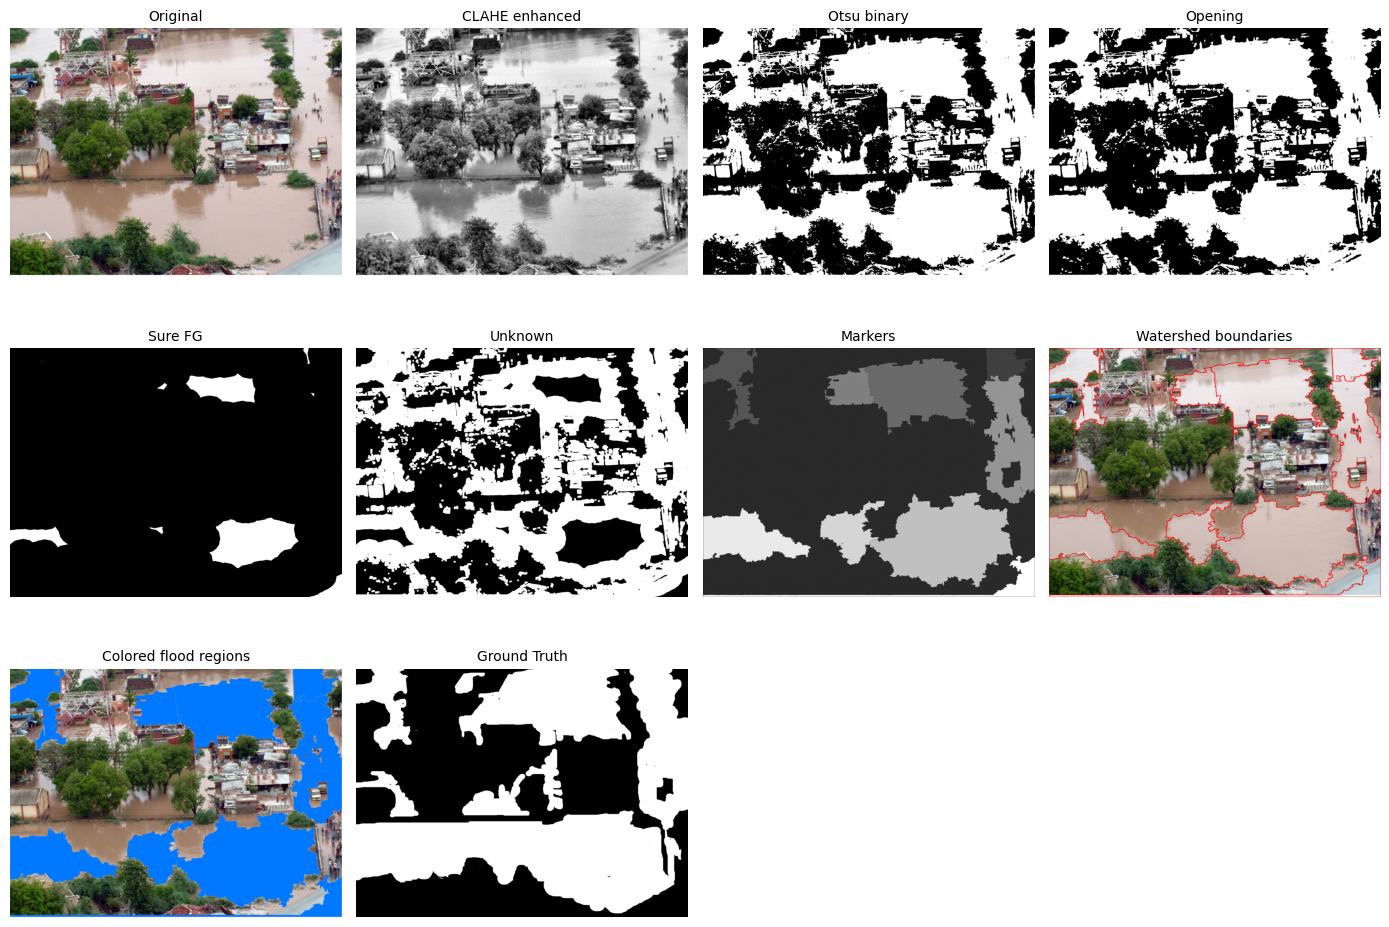

In [ ]:
plt.figure(figsize=(14, 10))

imgs = [orig, enhanced, binary, opening, sure_fg, unknown,
        markers, result, flood_colored, ground_truth]
titles = ["Original", "CLAHE enhanced", "Otsu binary", "Opening",
          "Sure FG", "Unknown", "Markers", "Watershed boundaries",
          "Colored flood regions", "Ground Truth"]

for i, (im, title) in enumerate(zip(imgs, titles), 1):
    plt.subplot(3, 4, i)
    if len(im.shape) == 2:
        plt.imshow(im, cmap='gray')
    else:
        plt.imshow(im)
    plt.title(title, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 10. Dice / IoU

In [ ]:
gt = (ground_truth > 127).astype(np.uint8)
pred = (flood_mask > 127).astype(np.uint8)
intersection = np.logical_and(pred, gt)
union = np.logical_or(pred, gt)

dice = 2. * intersection.sum() / (pred.sum() + gt.sum() + 1e-6)
iou  = intersection.sum() / (union.sum() + 1e-6)
print(f"Dice coefficient ≈ {dice:.4f}")
print(f"IoU               ≈ {iou:.4f}")

Dice coefficient ≈ 0.7710
IoU               ≈ 0.6273


# Table content

In [ ]:
import os
from pathlib import Path
import random
import pandas as pd

# Your paths
BASE_DIR = Path("/content/drive/MyDrive/flood-yolo-training/flood-dataset")
IMG_DIR  = BASE_DIR / "Image"
MASK_DIR = BASE_DIR / "Mask"
META_FILE = BASE_DIR / "metadata.csv"

# Count files
img_files = sorted(IMG_DIR.glob("*.jpg"))   # or *.jpeg if needed
mask_files = sorted(MASK_DIR.glob("*.png"))

print(f"Total RGB images found : {len(img_files)}")
print(f"Total masks found      : {len(mask_files)}")

# Optional: Verify metadata.csv mapping
if META_FILE.exists():
    df_meta = pd.read_csv(META_FILE)
    print("Metadata rows:", len(df_meta))
    print("Unique images in metadata:", df_meta['Image'].nunique())

# Create a random evaluation subset (e.g., 100 images)
random.seed(42)  # for reproducibility
eval_subset = random.sample(img_files, min(100, len(img_files)))

print("\nExample files from evaluation subset:")
for f in eval_subset[:5]:
    print(f.name)

# Optional: Save subset list to CSV for report reference
subset_df = pd.DataFrame({"image_file": [f.name for f in eval_subset]})
subset_df.to_csv("/content/evaluation_subset_100.csv", index=False)
print("Saved evaluation subset list to: /content/evaluation_subset_100.csv")

Total RGB images found : 290
Total masks found      : 290
Metadata rows: 290
Unique images in metadata: 290

Example files from evaluation subset:
1054.jpg
1009.jpg
2039.jpg
2024.jpg
2013.jpg
Saved evaluation subset list to: /content/evaluation_subset_100.csv


## Ablation + Quantitative Evaluation

In [ ]:
# ────────────────────────────────────────────────
#   CELL: Ablation + Quantitative Evaluation
# ────────────────────────────────────────────────

import time
import numpy as np
import cv2
from pathlib import Path
import random
import pandas as pd
from tqdm.auto import tqdm

# paths
BASE_DIR = Path("/content/drive/MyDrive/flood-yolo-training/flood-dataset")
IMG_DIR  = BASE_DIR / "Image"
MASK_DIR = BASE_DIR / "Mask"

# Get all images
img_files = sorted(IMG_DIR.glob("*.jpg"))
print(f"Found {len(img_files)} images")

# Random subset for evaluation (50–100 recommended)
random.seed(42)
eval_files = random.sample(img_files, min(80, len(img_files)))   # ← change size here
print(f"Evaluating on {len(eval_files)} images")

# ───────────── Helper: Dice & IoU ────────────────────────────────────────
def compute_dice_iou(pred_mask, gt_mask):
    pred_bin = (pred_mask > 127).astype(np.uint8)
    gt_bin   = (gt_mask > 127).astype(np.uint8)

    intersection = np.logical_and(pred_bin, gt_bin).sum()
    union        = np.logical_or(pred_bin, gt_bin).sum()

    dice = 2. * intersection / (pred_bin.sum() + gt_bin.sum() + 1e-8)
    iou  = intersection / (union + 1e-8)
    return dice, iou

# ───────────── WATERSHED PIPELINE FUNCTION ──────────────────────────

def run_watershed_pipeline(img_rgb, variant="full"):
    """
    variant options:
      'no_preprocess'     : raw gray → simple threshold or gradient watershed
      'gray_gaussian'     : gray + blur
      'gray_gaussian_clahe': + CLAHE
      'full'              : + opening + distance markers + watershed
    Returns: binary flood mask (uint8, 0/255)
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    if variant == "no_preprocess":
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
        return binary

    blurred = cv2.GaussianBlur(gray, (5,5), 0)

    if variant == "gray_gaussian":
        _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_OTSU)
        return binary

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(blurred)

    if variant == "gray_gaussian_clahe":
        _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_OTSU)
        return binary

    # Full pipeline
    _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_OTSU)
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    dist_t  = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_t, 0.4 * dist_t.max(), 255, 0)
    sure_fg = sure_fg.astype(np.uint8)

    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    markers = cv2.watershed(img_rgb, markers)
    flood_mask = (markers > 1).astype(np.uint8) * 255   # binary flood prediction

    return flood_mask

# ──── Run evaluation for each variant ───────────────────────────
variants = [
    "no_preprocess",
    "gray_gaussian",
    "gray_gaussian_clahe",
    "full"
]

results = {v: {"dice": [], "iou": [], "times": []} for v in variants}

for img_path in tqdm(eval_files, desc="Evaluating images"):
    img_rgb = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

    gt_path = MASK_DIR / (img_path.stem + ".png")
    gt = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)

    if gt is None:
        continue

    for variant in variants:
        t_start = time.time()
        pred_mask = run_watershed_pipeline(img_rgb, variant=variant)
        t_end   = time.time()

        dice, iou = compute_dice_iou(pred_mask, gt)

        results[variant]["dice"].append(dice)
        results[variant]["iou"].append(iou)
        results[variant]["times"].append(t_end - t_start)

# ──── Summarize results ─────────────────────────────────────────
print("\n=== Quantitative Results Summary ===")
for v in variants:
    mean_dice = np.mean(results[v]["dice"])
    mean_iou  = np.mean(results[v]["iou"])
    mean_time = np.mean(results[v]["times"]) * 1000  # ms
    print(f"{v:20s} | Dice: {mean_dice:.4f} | IoU: {mean_iou:.4f} | Avg time: {mean_time:.1f} ms")

print("\nSuggested Table 6.1 (full pipeline):")
print(f"Mean Dice: {np.mean(results['full']['dice']):.4f}")
print(f"Mean IoU : {np.mean(results['full']['iou']):.4f}")
print(f"Avg inference time per image: {np.mean(results['full']['times'])*1000:.1f} ms (CPU)")

# Export to CSV for easy copy to report
summary_df = pd.DataFrame({
    "Variant": variants,
    "Mean Dice": [np.mean(results[v]["dice"]) for v in variants],
    "Mean IoU":  [np.mean(results[v]["iou"]) for v in variants],
    "Avg Time (ms)": [np.mean(results[v]["times"])*1000 for v in variants]
})
summary_df.to_csv("/content/ablation_results.csv", index=False)
print("\nSaved to /content/ablation_results.csv → download and use for report tables")

Found 290 images
Evaluating on 80 images


Evaluating images:   0%|          | 0/80 [00:00<?, ?it/s]


=== Quantitative Results Summary ===
no_preprocess        | Dice: 0.6527 | IoU: 0.5242 | Avg time: 3.2 ms
gray_gaussian        | Dice: 0.6653 | IoU: 0.5367 | Avg time: 4.8 ms
gray_gaussian_clahe  | Dice: 0.6570 | IoU: 0.5144 | Avg time: 17.7 ms
full                 | Dice: 0.6579 | IoU: 0.5322 | Avg time: 138.0 ms

Suggested Table 6.1 (full pipeline):
Mean Dice: 0.6579
Mean IoU : 0.5322
Avg inference time per image: 138.0 ms (CPU)

Saved to /content/ablation_results.csv → download and use for report tables


## Confusion Matrix Analysis (binary: Flood vs Non-Flood)

In [ ]:
# accumulate totals
total_tp = total_tn = total_fp = total_fn = 0

# Inside variant loop, after pred_mask
pred_bin = (pred_mask > 127).astype(np.uint8)
gt_bin   = (gt > 127).astype(np.uint8)

# Resize prediction to match ground truth
pred_bin = cv2.resize(pred_bin, (gt_bin.shape[1], gt_bin.shape[0]), interpolation=cv2.INTER_NEAREST)

tp = np.logical_and(pred_bin, gt_bin).sum()
fp = np.logical_and(pred_bin, ~gt_bin).sum()
fn = np.logical_and(~pred_bin, gt_bin).sum()
tn = np.logical_and(~pred_bin, ~gt_bin).sum()

total_tp += tp; total_fp += fp; total_fn += fn; total_tn += tn
print(f"TP: {total_tp}, FP: {total_fp}, FN: {total_fn}, TN: {total_tn}")

TP: 219234, FP: 303984, FN: 297991, TN: 1326919


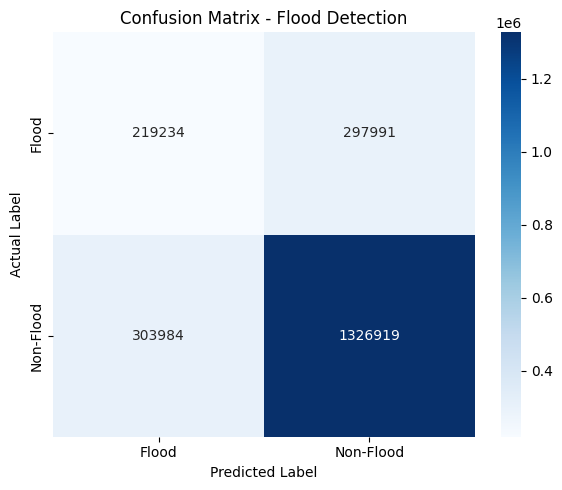

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix values
cm = np.array([
    [219234, 297991],   # Actual Flood → [TP, FN]
    [303984, 1326919]   # Actual Non-Flood → [FP, TN]
])

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Flood", "Non-Flood"],
            yticklabels=["Flood", "Non-Flood"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Flood Detection")

plt.tight_layout()
plt.show()

plt.savefig("confusion_matrix.png", dpi=300)

<Axes: >

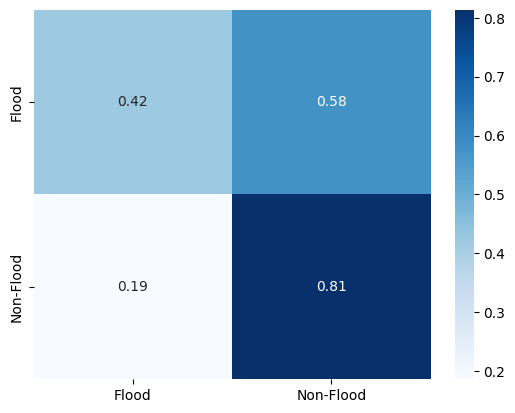

In [ ]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=["Flood", "Non-Flood"],
            yticklabels=["Flood", "Non-Flood"])

# Screenshots

In [ ]:
# ────────────────────────────────────────────────
#   SAVE INDIVIDUAL IMAGES FOR APPENDIX B
# ────────────────────────────────────────────────

import os

save_dir = "/content/screenshots_appendix_b"
os.makedirs(save_dir, exist_ok=True)

# Helper to save image (handles gray & RGB automatically)
def save_img(img, fname):
    path = os.path.join(save_dir, fname)
    if len(img.shape) == 2:  # grayscale
        cv2.imwrite(path, img)
    else:                    # RGB
        cv2.imwrite(path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    print(f"Saved: {path}")

# Now save each one
save_img(orig,          "01_original.jpg")
save_img(enhanced,      "02_clahe_enhanced.jpg")
save_img(binary,        "03_otsu_binary.jpg")
save_img(opening,       "04_opening.jpg")
save_img(sure_fg,       "05_sure_foreground.jpg")
save_img(unknown,       "06_unknown_region.jpg")

# Markers usually looks better with colormap
markers_vis = cv2.applyColorMap((markers * 25).astype(np.uint8), cv2.COLORMAP_JET)
save_img(markers_vis,   "07_markers_colored.jpg")

save_img(result,        "08_watershed_boundaries.jpg")
save_img(flood_colored, "09_colored_flood_regions.jpg")
save_img(ground_truth,  "10_ground_truth.jpg")

print(f"\nAll 10 screenshots saved in: {save_dir}")
print("Download the folder from Colab → Files → right-click → Download")

Saved: /content/screenshots_appendix_b/01_original.jpg
Saved: /content/screenshots_appendix_b/02_clahe_enhanced.jpg
Saved: /content/screenshots_appendix_b/03_otsu_binary.jpg
Saved: /content/screenshots_appendix_b/04_opening.jpg
Saved: /content/screenshots_appendix_b/05_sure_foreground.jpg
Saved: /content/screenshots_appendix_b/06_unknown_region.jpg
Saved: /content/screenshots_appendix_b/07_markers_colored.jpg
Saved: /content/screenshots_appendix_b/08_watershed_boundaries.jpg
Saved: /content/screenshots_appendix_b/09_colored_flood_regions.jpg
Saved: /content/screenshots_appendix_b/10_ground_truth.jpg

All 10 screenshots saved in: /content/screenshots_appendix_b
Download the folder from Colab → Files → right-click → Download


In [ ]:
save_img(result,        "08_watershed_boundaries.jpg")

Saved: /content/screenshots_appendix_b/08_watershed_boundaries.jpg
